# 🧠 Sistemas Inteligentes — Unidad IV
## Estrategias en la Solución de Problemas: Algoritmos de Búsqueda

---

> **Dr. Oscar Gabriel Vizcaíno Monroy**  
> Universidad Autónoma de Nayarit — Unidad Académica de Economía

---

### ¿Qué aprenderás en este notebook?

Este notebook está diseñado para que **comprendas, programes y apliques** los principales algoritmos de búsqueda en Inteligencia Artificial. Al finalizar serás capaz de:

✅ Entender cómo funciona cada algoritmo paso a paso  
✅ Programarlos en Python desde cero  
✅ Visualizar su comportamiento con ejemplos gráficos  
✅ Aplicarlos a un **caso real de la vida cotidiana**

### Temas cubiertos
1. Búsqueda Primero en Anchura (BFS)
2. Búsqueda Primero en Profundidad (DFS)
3. Algoritmo A\*
4. Búsqueda con Profundidad Iterativa (IDS)
5. Búsqueda Bidireccional
6. Hill Climbing (Ascenso a Colina)
7. Algoritmo Primero el Mejor (Best-First)
8. Búsqueda Beam
9. Algoritmo Minimax (para juegos)
10. 🏠 **Caso de Estudio Real: Robot doméstico que navega en tu hogar**

---

In [1]:
# ============================================================
# CELDA 1 — INSTALACIÓN DE LIBRERÍAS
# ============================================================
# Instalamos las librerías que necesitaremos para visualizar
# grafos y resultados de los algoritmos.
# networkx → para representar y dibujar grafos
# matplotlib → para mostrar las visualizaciones

!pip install networkx matplotlib --quiet

print("✅ Librerías instaladas correctamente")

✅ Librerías instaladas correctamente


In [2]:
# ============================================================
# CELDA 2 — IMPORTACIONES
# ============================================================
# Importamos todo lo que usaremos a lo largo del notebook.

import networkx as nx          # Para crear y manejar grafos
import matplotlib.pyplot as plt  # Para dibujar y visualizar
import matplotlib.patches as mpatches
import heapq                   # Para manejar colas de prioridad (montículos)
from collections import deque  # Para colas eficientes (deque = double-ended queue)
import math                    # Funciones matemáticas
import time                    # Para medir tiempos de ejecución

# Configuramos matplotlib para que las figuras se vean bien
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("✅ Importaciones listas")

✅ Importaciones listas


---
## 📌 CONCEPTOS PREVIOS: ¿Qué es un grafo y por qué lo usamos?

Antes de programar cualquier algoritmo de búsqueda necesitamos entender la estructura de datos sobre la que operan: **el grafo**.

Un **grafo** es una colección de:
- **Nodos (vértices):** representan estados o posiciones (ciudades, habitaciones, posiciones de un mapa, etc.)
- **Aristas (edges):** representan las conexiones o caminos entre nodos

En los algoritmos de búsqueda, el grafo modela el **espacio de estados** del problema: cada nodo es una posible situación y cada arista es una acción que te lleva de un estado a otro.

---

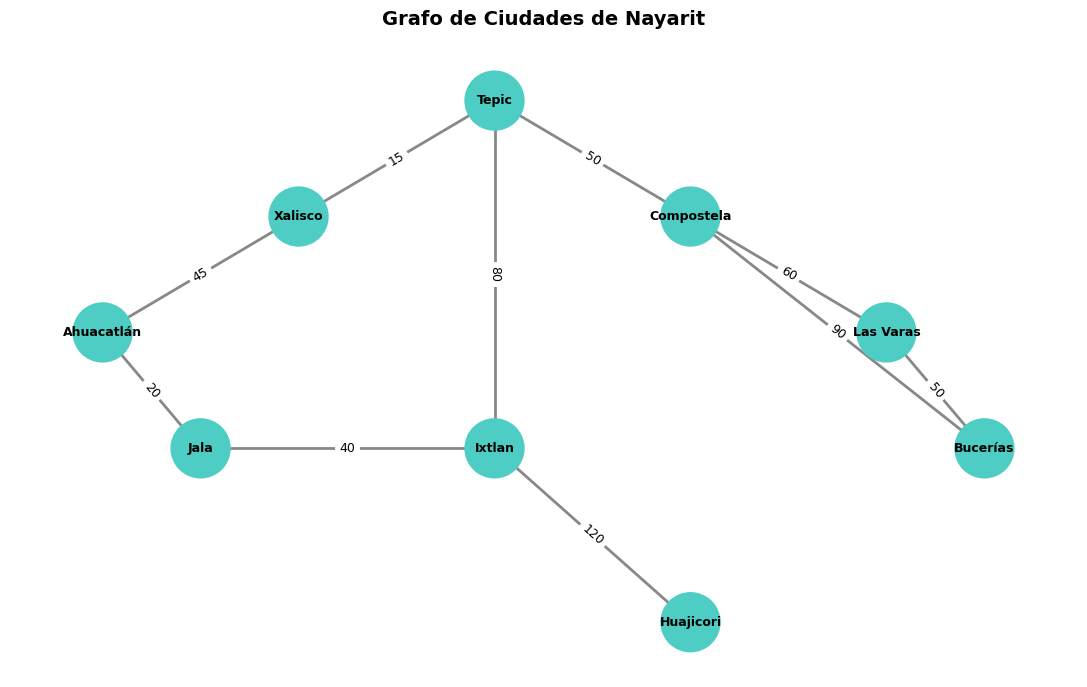


📌 Este grafo representa ciudades de Nayarit con distancias en km.
Los algoritmos de búsqueda intentarán encontrar rutas entre ciudades.


In [6]:
# ============================================================
# CELDA 3 — NUESTRO GRAFO DE EJEMPLO
# ============================================================
# Para todos los algoritmos usaremos el mismo grafo base.
# Imaginemos que son ciudades de Nayarit conectadas por carreteras.
#
# El grafo se representa como un diccionario:
#   clave: nodo actual
#   valor: lista de vecinos (y sus costos de viaje en km)

# Grafo con pesos (costos de viaje entre ciudades)
grafo_ciudades = {
    'Tepic':        [('Compostela', 50), ('Xalisco', 15), ('Ixtlan', 80)],
    'Xalisco':      [('Tepic', 15), ('Ahuacatlán', 45)],
    'Compostela':   [('Tepic', 50), ('Las Varas', 60), ('Bucerías', 90)],
    'Ahuacatlán':   [('Xalisco', 45), ('Jala', 20)],
    'Jala':         [('Ahuacatlán', 20), ('Ixtlan', 40)],
    'Ixtlan':       [('Tepic', 80), ('Jala', 40), ('Huajicori', 120)],
    'Las Varas':    [('Compostela', 60), ('Bucerías', 50)],
    'Bucerías':     [('Las Varas', 50), ('Compostela', 90)],
    'Huajicori':    [('Ixtlan', 120)]
}

# ----- VISUALIZACIÓN DEL GRAFO -----
def visualizar_grafo(grafo, titulo="Grafo de Ciudades de Nayarit",
                     resaltados=None, colores=None):
    """
    Esta función convierte nuestro diccionario en un grafo visual.
    Parámetros:
      grafo: diccionario de adyacencia
      titulo: título de la figura
      resaltados: lista de nodos a resaltar
      colores: diccionario nodo → color
    """
    # Creamos un grafo no dirigido con networkx
    G = nx.Graph()

    # Agregamos todas las aristas con sus pesos
    for nodo, vecinos in grafo.items():
        for vecino, costo in vecinos:
            G.add_edge(nodo, vecino, weight=costo)

    # Posiciones manuales para que se vea como un mapa real
    pos = {
        'Tepic':      (0, 2),
        'Xalisco':    (-1, 1),
        'Compostela': (1, 1),
        'Ahuacatlán': (-2, 0),
        'Jala':       (-1.5, -1),
        'Ixtlan':     (0, -1),
        'Las Varas':  (2, 0),
        'Bucerías':   (2.5, -1),
        'Huajicori':  (1, -2.5)
    }

    # Determinamos el color de cada nodo
    color_nodos = []
    for nodo in G.nodes():
        if colores and nodo in colores:
            color_nodos.append(colores[nodo])
        elif resaltados and nodo in resaltados:
            color_nodos.append('#FF6B6B')  # rojo para resaltados
        else:
            color_nodos.append('#4ECDC4')  # verde-azul por defecto

    fig, ax = plt.subplots(figsize=(11, 7))

    # Dibujamos nodos, aristas y etiquetas
    nx.draw(G, pos, with_labels=True, node_color=color_nodos,
            node_size=1800, font_size=9, font_weight='bold',
            edge_color='#888888', width=2, ax=ax)

    # Etiquetas de peso en las aristas (los km entre ciudades)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                  font_size=9, ax=ax)

    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

# Mostramos el grafo
visualizar_grafo(grafo_ciudades)
print("\n📌 Este grafo representa ciudades de Nayarit con distancias en km.")
print("Los algoritmos de búsqueda intentarán encontrar rutas entre ciudades.")

---
## 🔵 1. BÚSQUEDA PRIMERO EN ANCHURA (BFS — Breadth-First Search)

### Concepto
**BFS explora el grafo nivel por nivel.** Primero visita todos los vecinos del nodo inicial, luego todos los vecinos de esos vecinos, y así sucesivamente.

### Principio clave
Usa una **cola FIFO** (First In, First Out): el primer nodo que entra es el primero que se procesa. Esto garantiza que siempre se exploran los nodos más cercanos primero.

### ¿Cuándo usarlo?
- Cuando quieres encontrar el **camino más corto** (en número de pasos)
- Cuando el grafo no tiene pesos o todos los pesos son iguales

### Complejidad
- **Tiempo:** O(V + E) donde V = vértices, E = aristas
- **Espacio:** O(V) — guarda todos los nodos en memoria

---

In [7]:
# ============================================================
# CELDA 4 — IMPLEMENTACIÓN DE BFS
# ============================================================

def bfs(grafo, inicio, objetivo):
    """
    Búsqueda Primero en Anchura (BFS).

    Parámetros:
      grafo   : diccionario de adyacencia {nodo: [(vecino, costo), ...]}
      inicio  : nodo donde comenzamos la búsqueda
      objetivo: nodo que queremos encontrar

    Retorna:
      camino  : lista de nodos desde inicio hasta objetivo
      visitados: orden en que se visitaron los nodos
    """

    # --- PASO 1: Inicialización ---
    # 'cola' almacena tuplas (camino_hasta_ahora)
    # Comenzamos con un camino que solo contiene el nodo inicial
    cola = deque([[inicio]])        # deque es más eficiente que list para pop(0)

    # 'visitados' evita que revisitemos el mismo nodo (evitar ciclos)
    visitados = set()               # set = conjunto, búsqueda O(1)
    visitados.add(inicio)

    orden_visita = []               # registramos el orden de exploración

    # --- PASO 2: Bucle principal ---
    while cola:                     # mientras la cola no esté vacía

        # Extraemos el primer camino de la cola (FIFO)
        camino_actual = cola.popleft()

        # El nodo actual es el ÚLTIMO del camino actual
        nodo_actual = camino_actual[-1]

        orden_visita.append(nodo_actual)  # registramos la visita

        # --- PASO 3: ¿Llegamos al objetivo? ---
        if nodo_actual == objetivo:
            return camino_actual, orden_visita  # ¡Éxito!

        # --- PASO 4: Expandir vecinos ---
        # Obtenemos todos los vecinos del nodo actual
        for vecino, _ in grafo.get(nodo_actual, []):
            # Solo procesamos vecinos que no hemos visitado
            if vecino not in visitados:
                visitados.add(vecino)          # marcamos como visitado
                nuevo_camino = camino_actual + [vecino]  # extendemos el camino
                cola.append(nuevo_camino)      # agregamos al FINAL de la cola

    # Si la cola se vacía sin encontrar el objetivo → no hay solución
    return None, orden_visita


# ----- EJECUTAMOS BFS -----
print("=" * 55)
print("🔵 BÚSQUEDA PRIMERO EN ANCHURA (BFS)")
print("=" * 55)
print("Buscando ruta: Tepic → Bucerías")
print()

camino_bfs, orden_bfs = bfs(grafo_ciudades, 'Tepic', 'Bucerías')

print(f"📋 Orden de exploración: {' → '.join(orden_bfs)}")
print()

if camino_bfs:
    print(f"✅ Camino encontrado: {' → '.join(camino_bfs)}")
    print(f"   Número de pasos: {len(camino_bfs) - 1}")
else:
    print("❌ No se encontró camino")

🔵 BÚSQUEDA PRIMERO EN ANCHURA (BFS)
Buscando ruta: Tepic → Bucerías

📋 Orden de exploración: Tepic → Compostela → Xalisco → Ixtlan → Las Varas → Bucerías

✅ Camino encontrado: Tepic → Compostela → Bucerías
   Número de pasos: 2


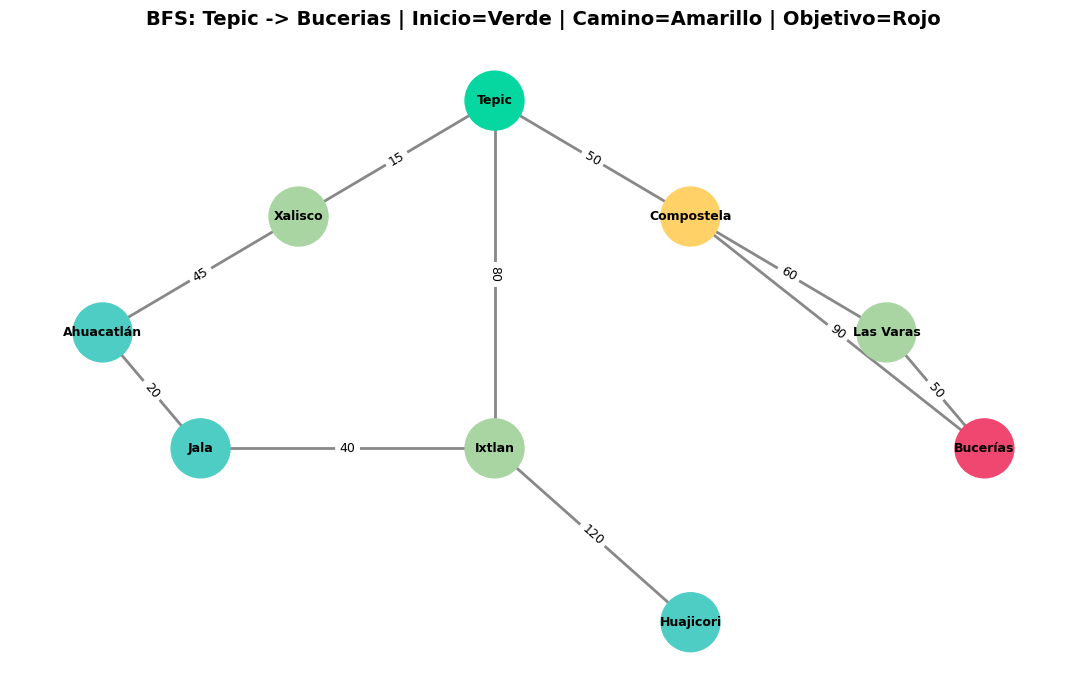


CLAVE PARA ENTENDER BFS:
   Verde claro   = nodos visitados
   Amarillo      = camino encontrado
   Verde intenso = nodo inicial
   Rojo          = nodo objetivo

BFS explora en 'anillos' alrededor del inicio.
Primero revisa los vecinos directos, luego los vecinos de esos vecinos, y así sucesivamente.
Por eso BFS garantiza encontrar el camino más corto en número de pasos.


In [12]:
# ============================================================
# CELDA 5 — VISUALIZACIÓN DE BFS
# ============================================================

# Construimos un diccionario de colores para visualizar:
#   Verde claro  = nodos visitados
#   Amarillo     = camino final encontrado
#   Verde intenso= nodo inicial
#   Rojo         = nodo objetivo

colores_bfs = {}

# 1. Pintamos todos los nodos visitados por BFS
for nodo in orden_bfs:
    colores_bfs[nodo] = '#A8D5A2'   # verde claro

# 2. Si se encontró camino, pintamos los nodos del camino
if camino_bfs:
    for nodo in camino_bfs:
        colores_bfs[nodo] = '#FFD166'   # amarillo

    # 3. Resaltamos el nodo inicial
    colores_bfs[camino_bfs[0]] = '#06D6A0'   # verde intenso

    # 4. Resaltamos el nodo objetivo
    colores_bfs[camino_bfs[-1]] = '#EF476F'  # rojo

# 5. Dibujamos el grafo usando la función que ya habías definido
visualizar_grafo(
    grafo_ciudades,
    titulo="BFS: Tepic -> Bucerias | Inicio=Verde | Camino=Amarillo | Objetivo=Rojo",
    colores=colores_bfs
)

# 6. Explicación en consola
print("\nCLAVE PARA ENTENDER BFS:")
print("   Verde claro   = nodos visitados")
print("   Amarillo      = camino encontrado")
print("   Verde intenso = nodo inicial")
print("   Rojo          = nodo objetivo")

print("\nBFS explora en 'anillos' alrededor del inicio.")
print("Primero revisa los vecinos directos, luego los vecinos de esos vecinos, y así sucesivamente.")
print("Por eso BFS garantiza encontrar el camino más corto en número de pasos.")

---
## 🟣 2. BÚSQUEDA PRIMERO EN PROFUNDIDAD (DFS — Depth-First Search)

### Concepto
**DFS explora tan profundo como sea posible** antes de retroceder. Sigue un camino hasta llegar a un callejón sin salida o al objetivo, y luego regresa para probar otra dirección.

### Principio clave
Usa una **pila LIFO** (Last In, First Out): el último nodo que entra es el primero en procesarse. Esto hace que siempre sigamos el camino más reciente.

### ¿Cuándo usarlo?
- Cuando la memoria es limitada (usa mucho menos que BFS)
- Cuando el objetivo está en las profundidades del grafo
- Para explorar todas las posibilidades (backtracking)

### Desventaja
**No garantiza** encontrar el camino más corto.

---

In [9]:
# ============================================================
# CELDA 6 — IMPLEMENTACIÓN DE DFS
# ============================================================

def dfs(grafo, inicio, objetivo):
    """
    Búsqueda Primero en Profundidad (DFS).

    La diferencia clave con BFS:
      BFS → usa deque.popleft()  → cola FIFO (primero en entrar, primero en salir)
      DFS → usa list.pop()       → pila LIFO (último en entrar, primero en salir)
    """

    # Usamos una lista como pila (stack)
    pila = [[inicio]]           # pila de caminos
    visitados = set()
    visitados.add(inicio)
    orden_visita = []

    while pila:
        # pop() extrae el ÚLTIMO elemento → comportamiento LIFO
        camino_actual = pila.pop()
        nodo_actual = camino_actual[-1]

        orden_visita.append(nodo_actual)

        if nodo_actual == objetivo:
            return camino_actual, orden_visita

        # Expandemos vecinos (en orden inverso para mantener
        # el orden de exploración intuitivo)
        for vecino, _ in reversed(grafo.get(nodo_actual, [])):
            if vecino not in visitados:
                visitados.add(vecino)
                nuevo_camino = camino_actual + [vecino]
                # Insertamos al INICIO de la pila (append → pop → LIFO)
                pila.append(nuevo_camino)

    return None, orden_visita


# ----- EJECUTAMOS DFS -----
print("=" * 55)
print("🟣 BÚSQUEDA PRIMERO EN PROFUNDIDAD (DFS)")
print("=" * 55)
print("Buscando ruta: Tepic → Bucerías")
print()

camino_dfs, orden_dfs = dfs(grafo_ciudades, 'Tepic', 'Bucerías')

print(f"📋 Orden de exploración: {' → '.join(orden_dfs)}")
print()

if camino_dfs:
    print(f"✅ Camino encontrado: {' → '.join(camino_dfs)}")
    print(f"   Número de pasos: {len(camino_dfs) - 1}")

print()
print("📊 COMPARATIVA BFS vs DFS:")
print(f"   BFS encontró: {' → '.join(camino_bfs) if camino_bfs else 'No encontrado'}")
print(f"   DFS encontró: {' → '.join(camino_dfs) if camino_dfs else 'No encontrado'}")
print()
print("💡 Observa: ambos llegan al objetivo pero pueden tomar RUTAS DIFERENTES.")
print("   BFS siempre da el mínimo de pasos, DFS puede dar una ruta más larga.")

🟣 BÚSQUEDA PRIMERO EN PROFUNDIDAD (DFS)
Buscando ruta: Tepic → Bucerías

📋 Orden de exploración: Tepic → Compostela → Las Varas → Bucerías

✅ Camino encontrado: Tepic → Compostela → Bucerías
   Número de pasos: 2

📊 COMPARATIVA BFS vs DFS:
   BFS encontró: Tepic → Compostela → Bucerías
   DFS encontró: Tepic → Compostela → Bucerías

💡 Observa: ambos llegan al objetivo pero pueden tomar RUTAS DIFERENTES.
   BFS siempre da el mínimo de pasos, DFS puede dar una ruta más larga.


---
## ⭐ 3. ALGORITMO A* (A-Estrella)

### Concepto
A\* es el **algoritmo de búsqueda más inteligente** de los clásicos. Combina:
- **g(n):** el costo real acumulado desde el inicio hasta el nodo `n`
- **h(n):** una estimación heurística del costo restante desde `n` hasta el objetivo

**f(n) = g(n) + h(n)** → función de evaluación

### La heurística
La **heurística** es una "función de pista" que nos da una estimación inteligente. Para ser válida (admisible), nunca debe sobreestimar el costo real:

> **h(n) ≤ h*(n)** para todo nodo n

### ¿Por qué es el mejor?
A\* **garantiza encontrar la solución óptima** si la heurística es admisible. Es más eficiente que BFS y DFS porque prioriza los caminos más prometedores.

---

In [10]:
# ============================================================
# CELDA 7 — IMPLEMENTACIÓN DE A*
# ============================================================

# Primero definimos las heurísticas (estimaciones de distancia al objetivo)
# Estas representan la distancia aérea aproximada a Bucerías (nuestro objetivo)
# En un problema real, usaríamos distancia euclidiana entre coordenadas GPS.

heuristica_a_buce = {
    'Tepic':      140,
    'Xalisco':    155,
    'Compostela':  90,
    'Ahuacatlán': 180,
    'Jala':       200,
    'Ixtlan':     220,
    'Las Varas':   50,
    'Bucerías':     0,   # el objetivo tiene costo 0
    'Huajicori':  300
}


def a_estrella(grafo, inicio, objetivo, heuristica):
    """
    Algoritmo A*.

    Parámetros:
      grafo     : diccionario de adyacencia
      inicio    : nodo de inicio
      objetivo  : nodo destino
      heuristica: diccionario {nodo: estimación_al_objetivo}

    Retorna:
      camino    : lista de nodos del camino óptimo
      costo_total: costo real del camino
      explorados: nodos que se evaluaron
    """

    # La 'frontera' es una cola de prioridad (min-heap)
    # Cada elemento: (f_valor, costo_g, nodo_actual, camino)
    # heapq siempre extrae el elemento con MENOR f_valor
    frontera = []
    heapq.heappush(frontera, (heuristica[inicio], 0, inicio, [inicio]))
    #                          ↑ f(inicio)         ↑ g=0  ↑ nodo  ↑ camino

    # Diccionario de costos mínimos conocidos para cada nodo
    costo_hasta = {inicio: 0}

    explorados = []  # nodos procesados en orden

    while frontera:
        # Extraemos el nodo con menor f(n) = g(n) + h(n)
        f_val, g_val, nodo_actual, camino_actual = heapq.heappop(frontera)

        explorados.append(nodo_actual)

        # ¿Llegamos al objetivo?
        if nodo_actual == objetivo:
            return camino_actual, g_val, explorados

        # Expandimos vecinos
        for vecino, costo_arista in grafo.get(nodo_actual, []):

            # g_nuevo = costo acumulado para llegar a 'vecino'
            g_nuevo = g_val + costo_arista

            # Solo procesamos si encontramos un camino MEJOR al vecino
            if vecino not in costo_hasta or g_nuevo < costo_hasta[vecino]:
                costo_hasta[vecino] = g_nuevo

                # f(vecino) = g_nuevo + h(vecino)
                h_vecino = heuristica.get(vecino, 0)
                f_nuevo = g_nuevo + h_vecino

                nuevo_camino = camino_actual + [vecino]
                heapq.heappush(frontera, (f_nuevo, g_nuevo, vecino, nuevo_camino))

    return None, float('inf'), explorados


# ----- EJECUTAMOS A* -----
print("=" * 55)
print("⭐ ALGORITMO A* (A-Estrella)")
print("=" * 55)
print("Buscando RUTA ÓPTIMA: Tepic → Bucerías")
print()
print("📊 Heurísticas usadas (dist. estimada a Bucerías):")
for ciudad, h in heuristica_a_buce.items():
    print(f"   {ciudad:15s}: {h} km estimados")
print()

camino_astar, costo_astar, explorados_astar = a_estrella(
    grafo_ciudades, 'Tepic', 'Bucerías', heuristica_a_buce
)

print(f"📋 Nodos explorados: {' → '.join(explorados_astar)}")
print()

if camino_astar:
    print(f"✅ Ruta óptima: {' → '.join(camino_astar)}")
    print(f"   Costo total real: {costo_astar} km")
    print(f"   Nodos explorados: {len(explorados_astar)}")

⭐ ALGORITMO A* (A-Estrella)
Buscando RUTA ÓPTIMA: Tepic → Bucerías

📊 Heurísticas usadas (dist. estimada a Bucerías):
   Tepic          : 140 km estimados
   Xalisco        : 155 km estimados
   Compostela     : 90 km estimados
   Ahuacatlán     : 180 km estimados
   Jala           : 200 km estimados
   Ixtlan         : 220 km estimados
   Las Varas      : 50 km estimados
   Bucerías       : 0 km estimados
   Huajicori      : 300 km estimados

📋 Nodos explorados: Tepic → Compostela → Bucerías

✅ Ruta óptima: Tepic → Compostela → Bucerías
   Costo total real: 140 km
   Nodos explorados: 3


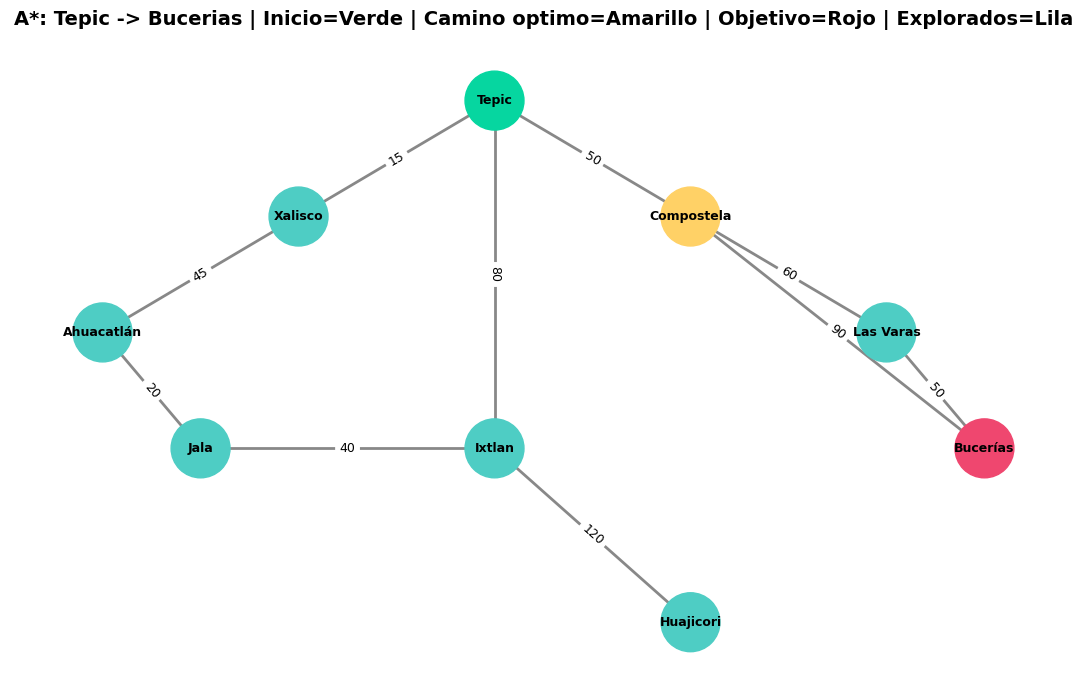


COMPARATIVA FINAL DE ALGORITMOS
-----------------------------------------------------------------
Algoritmo    Camino                                        Costo
-----------------------------------------------------------------
BFS          Tepic -> Compostela -> Bucerías              140 km
DFS          Tepic -> Compostela -> Bucerías              140 km
A*           Tepic -> Compostela -> Bucerías              140 km
-----------------------------------------------------------------

CLAVE DE INTERPRETACION:
A* combina el costo acumulado con una heuristica.
Por eso encuentra la ruta de menor costo real de forma mas eficiente que BFS y DFS.


In [19]:
# ============================================================
# CELDA 8 — VISUALIZACIÓN A* Y COMPARATIVA
# ============================================================

# Construimos un diccionario de colores para visualizar:
#   Lila          = nodos explorados por A*
#   Amarillo      = camino óptimo encontrado
#   Verde intenso = nodo inicial
#   Rojo          = nodo objetivo

colores_astar = {}

# 1. Pintamos todos los nodos explorados por A*
for nodo in explorados_astar:
    colores_astar[nodo] = '#C3B1E1'   # lila

# 2. Si se encontró camino, pintamos el camino óptimo
if camino_astar:
    for nodo in camino_astar:
        colores_astar[nodo] = '#FFD166'   # amarillo

    # 3. Resaltamos el nodo inicial
    colores_astar[camino_astar[0]] = '#06D6A0'   # verde intenso

    # 4. Resaltamos el nodo objetivo
    colores_astar[camino_astar[-1]] = '#EF476F'  # rojo

# 5. Dibujamos el grafo
visualizar_grafo(
    grafo_ciudades,
    titulo="A*: Tepic -> Bucerias | Inicio=Verde | Camino optimo=Amarillo | Objetivo=Rojo | Explorados=Lila",
    colores=colores_astar
)

# ============================================================
# TABLA COMPARATIVA
# ============================================================

print()
print("COMPARATIVA FINAL DE ALGORITMOS")
print("-" * 65)
print(f"{'Algoritmo':<12} {'Camino':40} {'Costo':>10}")
print("-" * 65)

# Función para calcular el costo total de una ruta
def calcular_costo(grafo, camino):
    costo = 0
    for i in range(len(camino) - 1):
        nodo = camino[i]
        siguiente = camino[i + 1]

        for vecino, c in grafo.get(nodo, []):
            if vecino == siguiente:
                costo += c
                break
    return costo

# Calculamos costos de BFS y DFS
costo_bfs = calcular_costo(grafo_ciudades, camino_bfs) if camino_bfs else '∞'
costo_dfs = calcular_costo(grafo_ciudades, camino_dfs) if camino_dfs else '∞'

# Convertimos rutas a texto
ruta_bfs = ' -> '.join(camino_bfs) if camino_bfs else 'No encontrado'
ruta_dfs = ' -> '.join(camino_dfs) if camino_dfs else 'No encontrado'
ruta_astar = ' -> '.join(camino_astar) if camino_astar else 'No encontrado'

# Imprimimos la tabla
print(f"{'BFS':<12} {ruta_bfs:40} {str(costo_bfs)+' km':>10}")
print(f"{'DFS':<12} {ruta_dfs:40} {str(costo_dfs)+' km':>10}")
print(f"{'A*':<12} {ruta_astar:40} {str(costo_astar)+' km':>10}")
print("-" * 65)

print("\nCLAVE DE INTERPRETACION:")
print("A* combina el costo acumulado con una heuristica.")
print("Por eso encuentra la ruta de menor costo real de forma mas eficiente que BFS y DFS.")

---
## 🔄 4. BÚSQUEDA CON PROFUNDIDAD ITERATIVA (IDS)

### Concepto
IDS combina lo mejor de BFS y DFS:
- De **DFS** toma: uso eficiente de memoria
- De **BFS** toma: garantía de encontrar el camino más corto

### ¿Cómo funciona?
Realiza múltiples DFS, **aumentando gradualmente el límite de profundidad**: primero solo profundidad 0, luego 1, luego 2... hasta encontrar el objetivo.

---

In [13]:
# ============================================================
# CELDA 9 — IMPLEMENTACIÓN DE IDS
# ============================================================

def dfs_limitado(grafo, camino_actual, objetivo, limite, visitados):
    """
    DFS con un límite máximo de profundidad.
    Función auxiliar para IDS.
    """
    nodo_actual = camino_actual[-1]

    # ¿Llegamos al objetivo?
    if nodo_actual == objetivo:
        return camino_actual

    # ¿Llegamos al límite de profundidad?
    # len(camino) - 1 = profundidad actual
    if len(camino_actual) - 1 >= limite:
        return None    # corte por límite

    # Expandir vecinos
    for vecino, _ in grafo.get(nodo_actual, []):
        if vecino not in visitados:
            visitados.add(vecino)
            resultado = dfs_limitado(
                grafo, camino_actual + [vecino],
                objetivo, limite, visitados
            )
            if resultado is not None:
                return resultado
            visitados.remove(vecino)   # backtracking: deshacemos la visita

    return None


def ids(grafo, inicio, objetivo, max_profundidad=20):
    """
    Iterative Deepening Search (IDS).
    Incrementa el límite de profundidad hasta encontrar el objetivo.
    """
    print(f"   Iterando límites de profundidad...")

    for limite in range(max_profundidad + 1):
        print(f"   🔍 Probando profundidad límite: {limite}", end="")
        visitados = {inicio}
        resultado = dfs_limitado(grafo, [inicio], objetivo, limite, visitados)

        if resultado is not None:
            print(f"  ← ✅ ENCONTRADO")
            return resultado, limite
        else:
            print(f"  — no encontrado")

    return None, -1


# ----- EJECUTAMOS IDS -----
print("=" * 55)
print("🔄 BÚSQUEDA CON PROFUNDIDAD ITERATIVA (IDS)")
print("=" * 55)
print("Buscando: Tepic → Bucerías")
print()

camino_ids, profundidad_ids = ids(grafo_ciudades, 'Tepic', 'Bucerías')

print()
if camino_ids:
    print(f"✅ Camino encontrado: {' → '.join(camino_ids)}")
    print(f"   Profundidad del objetivo: {profundidad_ids}")
    print()
    print("💡 IDS tiene la misma COMPLETITUD que BFS")
    print("   pero usa mucho MENOS memoria (similar a DFS).")

🔄 BÚSQUEDA CON PROFUNDIDAD ITERATIVA (IDS)
Buscando: Tepic → Bucerías

   Iterando límites de profundidad...
   🔍 Probando profundidad límite: 0  — no encontrado
   🔍 Probando profundidad límite: 1  — no encontrado
   🔍 Probando profundidad límite: 2  ← ✅ ENCONTRADO

✅ Camino encontrado: Tepic → Compostela → Bucerías
   Profundidad del objetivo: 2

💡 IDS tiene la misma COMPLETITUD que BFS
   pero usa mucho MENOS memoria (similar a DFS).


---
## ↔️ 5. BÚSQUEDA BIDIRECCIONAL

### Concepto
En lugar de buscar **solo desde el inicio hacia el objetivo**, la búsqueda bidireccional lanza **dos búsquedas simultáneas**:
1. **Hacia adelante:** desde el nodo inicial
2. **Hacia atrás:** desde el nodo objetivo

Se detiene cuando las dos fronteras **se encuentran en el medio**.

### ¿Por qué es eficiente?
Si el factor de ramificación es `b` y la solución está a profundidad `d`, BFS tradicional explora **O(b^d)** nodos. La bidireccional solo explora **O(2 × b^(d/2))** — ¡mucho menos!

---

In [14]:
# ============================================================
# CELDA 10 — BÚSQUEDA BIDIRECCIONAL
# ============================================================

def construir_grafo_inverso(grafo):
    """
    Crea el grafo invertido (para la búsqueda hacia atrás).
    Si A → B en el original, entonces B → A en el inverso.
    """
    inverso = {nodo: [] for nodo in grafo}
    for nodo, vecinos in grafo.items():
        for vecino, costo in vecinos:
            if vecino not in inverso:
                inverso[vecino] = []
            inverso[vecino].append((nodo, costo))
    return inverso


def busqueda_bidireccional(grafo, inicio, objetivo):
    """
    Búsqueda Bidireccional con BFS en ambas direcciones.
    """
    grafo_inv = construir_grafo_inverso(grafo)

    # Frontera hacia ADELANTE (desde inicio)
    frontera_adelante = deque([[inicio]])
    visitados_adelante = {inicio: [inicio]}  # nodo → camino desde inicio

    # Frontera hacia ATRÁS (desde objetivo)
    frontera_atras = deque([[objetivo]])
    visitados_atras = {objetivo: [objetivo]}  # nodo → camino desde objetivo

    paso = 0
    print("   Expandiendo ambas fronteras:")

    while frontera_adelante or frontera_atras:
        paso += 1

        # --- Expandir un paso hacia ADELANTE ---
        if frontera_adelante:
            camino = frontera_adelante.popleft()
            nodo = camino[-1]

            print(f"   ➡️  Adelante: {' → '.join(camino)}")

            for vecino, _ in grafo.get(nodo, []):
                if vecino not in visitados_adelante:
                    nuevo_camino = camino + [vecino]
                    visitados_adelante[vecino] = nuevo_camino
                    frontera_adelante.append(nuevo_camino)

                    # ¿Se encontraron las fronteras?
                    if vecino in visitados_atras:
                        # Combinamos los dos caminos
                        camino_atras = visitados_atras[vecino][::-1]  # invertimos
                        camino_completo = nuevo_camino + camino_atras[1:]
                        print(f"   ✅ ¡Fronteras encontradas en: {vecino}!")
                        return camino_completo

        # --- Expandir un paso hacia ATRÁS ---
        if frontera_atras:
            camino = frontera_atras.popleft()
            nodo = camino[-1]

            print(f"   ⬅️  Atrás:   {' → '.join(camino)}")

            for vecino, _ in grafo_inv.get(nodo, []):
                if vecino not in visitados_atras:
                    nuevo_camino = camino + [vecino]
                    visitados_atras[vecino] = nuevo_camino
                    frontera_atras.append(nuevo_camino)

                    if vecino in visitados_adelante:
                        camino_adelante = visitados_adelante[vecino]
                        camino_atras_inv = nuevo_camino[::-1]
                        camino_completo = camino_adelante + camino_atras_inv[1:]
                        print(f"   ✅ ¡Fronteras encontradas en: {vecino}!")
                        return camino_completo

    return None


# ----- EJECUTAMOS -----
print("=" * 55)
print("↔️  BÚSQUEDA BIDIRECCIONAL")
print("=" * 55)
print("Buscando: Tepic → Bucerías")
print()

camino_bidir = busqueda_bidireccional(grafo_ciudades, 'Tepic', 'Bucerías')

print()
if camino_bidir:
    print(f"✅ Camino encontrado: {' → '.join(camino_bidir)}")

↔️  BÚSQUEDA BIDIRECCIONAL
Buscando: Tepic → Bucerías

   Expandiendo ambas fronteras:
   ➡️  Adelante: Tepic
   ⬅️  Atrás:   Bucerías
   ✅ ¡Fronteras encontradas en: Compostela!

✅ Camino encontrado: Tepic → Compostela → Bucerías


---
## ⛰️ 6. HILL CLIMBING (Ascenso a Colina)

### Concepto
Hill Climbing es como **escalar una montaña con los ojos vendados**: en cada paso, eliges la dirección que te lleva más arriba (o al estado más prometedor).

### Proceso
1. Empieza en un estado inicial
2. Evalúa todos los estados vecinos
3. Si hay uno mejor → muévete a él
4. Si no hay ninguno mejor → **detente** (llegaste a un máximo local)

### Problemas
- **Máximos locales:** llegas a un punto donde ningún vecino es mejor, pero no es la solución óptima
- **Mesetas:** todos los vecinos tienen el mismo valor
- **Riscos:** requieres varios pasos para mejorar

---

In [15]:
# ============================================================
# CELDA 11 — HILL CLIMBING
# ============================================================

def hill_climbing(grafo, inicio, objetivo, heuristica):
    """
    Hill Climbing (Ascenso a Colina).

    Usamos la heurística como función de evaluación:
    MENOR h(n) = MÁS CERCA del objetivo = MEJOR estado.

    Hill Climbing siempre se mueve al vecino con MENOR h(n).
    """
    nodo_actual = inicio
    camino = [inicio]
    visitados = {inicio}

    print(f"   Inicio en: {inicio} | h={heuristica.get(inicio, '?')} km")

    while nodo_actual != objetivo:
        vecinos = grafo.get(nodo_actual, [])

        if not vecinos:
            print("   ❌ Sin vecinos — atascado")
            return camino, False

        # Evaluamos todos los vecinos no visitados
        mejores = []
        for vecino, _ in vecinos:
            if vecino not in visitados:
                h = heuristica.get(vecino, float('inf'))
                mejores.append((h, vecino))

        if not mejores:
            print("   ❌ Sin vecinos sin visitar — máximo local")
            return camino, False

        # Elegimos el vecino con MENOR h (más cercano al objetivo)
        mejores.sort()                 # ordena por h, de menor a mayor
        h_mejor, mejor_vecino = mejores[0]

        h_actual = heuristica.get(nodo_actual, float('inf'))

        # Solo nos movemos si el vecino es MEJOR que el estado actual
        if h_mejor < h_actual:
            print(f"   ↗️  {nodo_actual} (h={h_actual}) → {mejor_vecino} (h={h_mejor})")
            nodo_actual = mejor_vecino
            camino.append(nodo_actual)
            visitados.add(nodo_actual)
        else:
            print(f"   ⛰️  Máximo local en: {nodo_actual} (h={h_actual})")
            print(f"       El mejor vecino ({mejor_vecino}) tiene h={h_mejor} — no mejora")
            return camino, False

    print(f"   🎯 Objetivo alcanzado: {objetivo}")
    return camino, True


# ----- EJECUTAMOS -----
print("=" * 55)
print("⛰️  HILL CLIMBING (Ascenso a Colina)")
print("=" * 55)
print("Buscando: Tepic → Bucerías")
print()

camino_hc, exito_hc = hill_climbing(
    grafo_ciudades, 'Tepic', 'Bucerías', heuristica_a_buce
)

print()
estado = '✅ Éxito' if exito_hc else '❌ Atascado (máximo local)'
print(f"Resultado: {estado}")
print(f"Camino recorrido: {' → '.join(camino_hc)}")
print()
print("💡 Hill Climbing es MUY RÁPIDO pero puede quedar atascado.")
print("   Solución: reinicio aleatorio (Random Restart Hill Climbing).")

⛰️  HILL CLIMBING (Ascenso a Colina)
Buscando: Tepic → Bucerías

   Inicio en: Tepic | h=140 km
   ↗️  Tepic (h=140) → Compostela (h=90)
   ↗️  Compostela (h=90) → Bucerías (h=0)
   🎯 Objetivo alcanzado: Bucerías

Resultado: ✅ Éxito
Camino recorrido: Tepic → Compostela → Bucerías

💡 Hill Climbing es MUY RÁPIDO pero puede quedar atascado.
   Solución: reinicio aleatorio (Random Restart Hill Climbing).


---
## 🔦 7. BÚSQUEDA BEAM (Beam Search)

### Concepto
Beam Search es como BFS pero **solo mantiene los `k` nodos más prometedores** en cada nivel. El valor `k` se llama **beam width (ancho del haz)**.

- Si `k = 1` → equivale a Hill Climbing
- Si `k = ∞` → equivale a BFS completo

### Ventaja
Usa mucha **menos memoria** que BFS al precio de perder la garantía de optimalidad.

---

In [16]:
# ============================================================
# CELDA 12 — BÚSQUEDA BEAM
# ============================================================

def beam_search(grafo, inicio, objetivo, heuristica, beam_width=2):
    """
    Búsqueda Beam.

    Parámetros:
      beam_width: cuántos caminos mantenemos activos simultáneamente
    """
    # La 'viga' (beam) contiene los caminos activos
    # Cada elemento: (h_valor, camino)
    viga = [(heuristica.get(inicio, 0), [inicio])]

    nivel = 0

    while viga:
        nivel += 1
        print(f"   Nivel {nivel} — Viga activa ({len(viga)} caminos):")
        for h, cam in viga:
            print(f"     h={h:3d} | {' → '.join(cam)}")

        # Generamos todos los sucesores de todos los caminos en la viga
        sucesores = []
        for h_actual, camino_actual in viga:
            nodo_actual = camino_actual[-1]

            # ¿Llegamos al objetivo?
            if nodo_actual == objetivo:
                print(f"   ✅ Objetivo encontrado")
                return camino_actual

            # Expandimos vecinos
            nodos_en_camino = set(camino_actual)  # evitar ciclos
            for vecino, _ in grafo.get(nodo_actual, []):
                if vecino not in nodos_en_camino:
                    h_vecino = heuristica.get(vecino, float('inf'))
                    nuevo_camino = camino_actual + [vecino]
                    sucesores.append((h_vecino, nuevo_camino))

        if not sucesores:
            print("   ❌ Sin sucesores")
            return None

        # *** PODA: solo mantenemos los 'beam_width' mejores sucesores ***
        sucesores.sort(key=lambda x: x[0])   # ordena por heurística
        viga = sucesores[:beam_width]         # ¡nos quedamos solo con los mejores!

        print(f"   ✂️  Podando: mantenemos solo {beam_width} mejores")
        print()

    return None


# ----- EJECUTAMOS -----
print("=" * 55)
print("🔦 BÚSQUEDA BEAM (beam_width=2)")
print("=" * 55)
print("Buscando: Tepic → Bucerías")
print()

camino_beam = beam_search(
    grafo_ciudades, 'Tepic', 'Bucerías',
    heuristica_a_buce, beam_width=2
)

print()
if camino_beam:
    print(f"✅ Camino encontrado: {' → '.join(camino_beam)}")
else:
    print("❌ No se encontró camino (la poda eliminó el camino correcto)")
    print("   Prueba aumentando el beam_width")

🔦 BÚSQUEDA BEAM (beam_width=2)
Buscando: Tepic → Bucerías

   Nivel 1 — Viga activa (1 caminos):
     h=140 | Tepic
   ✂️  Podando: mantenemos solo 2 mejores

   Nivel 2 — Viga activa (2 caminos):
     h= 90 | Tepic → Compostela
     h=155 | Tepic → Xalisco
   ✂️  Podando: mantenemos solo 2 mejores

   Nivel 3 — Viga activa (2 caminos):
     h=  0 | Tepic → Compostela → Bucerías
     h= 50 | Tepic → Compostela → Las Varas
   ✅ Objetivo encontrado

✅ Camino encontrado: Tepic → Compostela → Bucerías


---
## 🎮 8. ALGORITMO MINIMAX (para Juegos)

### Concepto
Minimax es el algoritmo clásico para **juegos de dos jugadores** (ajedrez, tres en raya, damas).

- **Jugador MAX:** quiere maximizar su puntuación
- **Jugador MIN:** quiere minimizar la puntuación de MAX (el oponente)

### Funcionamiento
El algoritmo construye un **árbol de juego** con todos los movimientos posibles y usa búsqueda en profundidad para evaluar el mejor movimiento.

### Aplicaciones
- Tres en raya, ajedrez, damas
- Videojuegos (IA de personajes)
- Cualquier problema de adversario

---

In [17]:
# ============================================================
# CELDA 13 — MINIMAX: TRES EN RAYA COMPLETO
# ============================================================

# Representamos el tablero como una lista de 9 posiciones
# índices:  0 | 1 | 2
#           ---------
#           3 | 4 | 5
#           ---------
#           6 | 7 | 8

def verificar_ganador(tablero):
    """
    Verifica si hay un ganador en el tablero.
    Retorna 'X', 'O', o None.
    """
    # Todas las líneas ganadoras posibles
    lineas = [
        [0, 1, 2], [3, 4, 5], [6, 7, 8],  # horizontales
        [0, 3, 6], [1, 4, 7], [2, 5, 8],  # verticales
        [0, 4, 8], [2, 4, 6]              # diagonales
    ]
    for linea in lineas:
        a, b, c = linea
        if tablero[a] == tablero[b] == tablero[c] and tablero[a] != ' ':
            return tablero[a]
    return None


def tablero_lleno(tablero):
    """¿El tablero está completo?"""
    return ' ' not in tablero


def evaluar(tablero):
    """
    Función de evaluación estática:
      +10 → gana X (MAX)
       -10 → gana O (MIN)
        0 → empate o juego en curso
    """
    ganador = verificar_ganador(tablero)
    if ganador == 'X': return 10
    if ganador == 'O': return -10
    return 0


def minimax(tablero, profundidad, es_max, alfa=-math.inf, beta=math.inf):
    """
    Algoritmo Minimax con poda Alfa-Beta.

    Parámetros:
      tablero    : estado actual del juego
      profundidad: qué tan profundo estamos en el árbol
      es_max     : True si es el turno del jugador MAX (X)
      alfa, beta : para poda alfa-beta (optimización)

    Retorna:
      La mejor puntuación posible desde este estado.
    """
    puntuacion = evaluar(tablero)

    # Condiciones de parada (estados terminales)
    if puntuacion == 10:  return puntuacion - profundidad  # X gana pronto → más valor
    if puntuacion == -10: return puntuacion + profundidad  # O gana pronto → más costo
    if tablero_lleno(tablero): return 0                    # empate

    movimientos_posibles = [i for i, c in enumerate(tablero) if c == ' ']

    if es_max:  # Turno de MAX (X) — quiere maximizar
        mejor = -math.inf
        for mov in movimientos_posibles:
            tablero[mov] = 'X'                                        # hace el movimiento
            valor = minimax(tablero, profundidad + 1, False, alfa, beta)  # evalúa recursivamente
            tablero[mov] = ' '                                        # deshace el movimiento
            mejor = max(mejor, valor)
            alfa = max(alfa, mejor)
            if beta <= alfa: break  # poda: no necesitamos explorar más
        return mejor

    else:  # Turno de MIN (O) — quiere minimizar
        mejor = math.inf
        for mov in movimientos_posibles:
            tablero[mov] = 'O'
            valor = minimax(tablero, profundidad + 1, True, alfa, beta)
            tablero[mov] = ' '
            mejor = min(mejor, valor)
            beta = min(beta, mejor)
            if beta <= alfa: break
        return mejor


def mejor_jugada(tablero):
    """
    Encuentra el mejor movimiento para el jugador X (MAX)
    usando Minimax.
    """
    mejor_val = -math.inf
    mejor_mov = -1

    for i in range(9):
        if tablero[i] == ' ':
            tablero[i] = 'X'
            val = minimax(tablero, 0, False)
            tablero[i] = ' '
            if val > mejor_val:
                mejor_val = val
                mejor_mov = i

    return mejor_mov, mejor_val


def mostrar_tablero(tablero, titulo=""):
    """Imprime el tablero de manera bonita."""
    if titulo:
        print(f"   {titulo}")
    print(f"   {tablero[0]} | {tablero[1]} | {tablero[2]}")
    print("   ---------")
    print(f"   {tablero[3]} | {tablero[4]} | {tablero[5]}")
    print("   ---------")
    print(f"   {tablero[6]} | {tablero[7]} | {tablero[8]}")


# ----- DEMO DE MINIMAX -----
print("=" * 55)
print("🎮 MINIMAX — TRES EN RAYA")
print("=" * 55)
print()

# Estado inicial
tablero = ['O', 'X', ' ',
           ' ', ' ', ' ',
           ' ', ' ', 'O']

mostrar_tablero(tablero, "Tablero actual (turno de X):")
print()

movimiento, valor = mejor_jugada(tablero)

print(f"🤖 Minimax elige: posición {movimiento} (valor={valor})")
print(f"   Posiciones: 0=esq.sup.izq, 4=centro, 8=esq.inf.der")
print()

tablero[movimiento] = 'X'
mostrar_tablero(tablero, "Después del movimiento de X:")
ganador = verificar_ganador(tablero)
print()
if ganador:
    print(f"🏆 ¡Gana {ganador}!")
elif tablero_lleno(tablero):
    print("🤝 Empate")
else:
    print("▶️  El juego continúa...")

🎮 MINIMAX — TRES EN RAYA

   Tablero actual (turno de X):
   O | X |  
   ---------
     |   |  
   ---------
     |   | O

🤖 Minimax elige: posición 4 (valor=0)
   Posiciones: 0=esq.sup.izq, 4=centro, 8=esq.inf.der

   Después del movimiento de X:
   O | X |  
   ---------
     | X |  
   ---------
     |   | O

▶️  El juego continúa...


---
## 📊 RESUMEN COMPARATIVO DE TODOS LOS ALGORITMOS

---

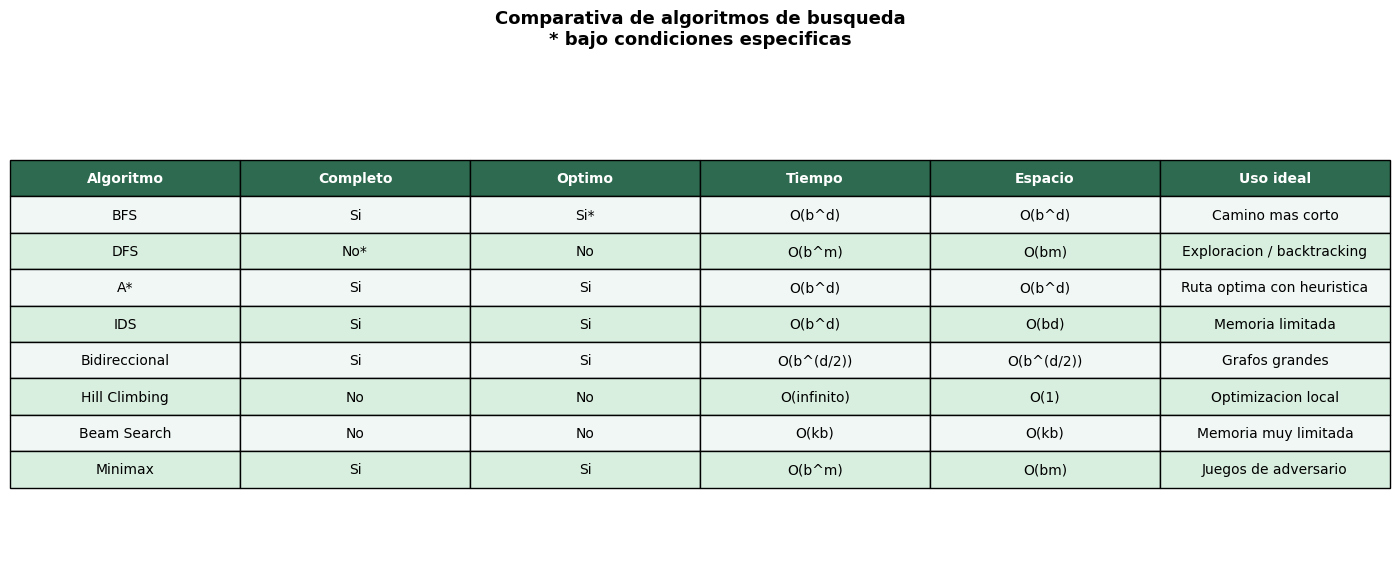

Leyenda:
b = factor de ramificacion
d = profundidad de la solucion
m = profundidad maxima del arbol
k = beam width
* = depende de condiciones especificas del problema


In [22]:
# ============================================================
# CELDA 14 — TABLA COMPARATIVA VISUAL
# ============================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

# Columnas de la tabla
columnas = ['Algoritmo', 'Completo', 'Optimo', 'Tiempo', 'Espacio', 'Uso ideal']

# Filas de la tabla
filas = [
    ['BFS',           'Si',    'Si*',  'O(b^d)',    'O(b^d)',    'Camino mas corto'],
    ['DFS',           'No*',   'No',   'O(b^m)',    'O(bm)',     'Exploracion / backtracking'],
    ['A*',            'Si',    'Si',   'O(b^d)',    'O(b^d)',    'Ruta optima con heuristica'],
    ['IDS',           'Si',    'Si',   'O(b^d)',    'O(bd)',     'Memoria limitada'],
    ['Bidireccional', 'Si',    'Si',   'O(b^(d/2))','O(b^(d/2))','Grafos grandes'],
    ['Hill Climbing', 'No',    'No',   'O(infinito)','O(1)',     'Optimizacion local'],
    ['Beam Search',   'No',    'No',   'O(kb)',     'O(kb)',     'Memoria muy limitada'],
    ['Minimax',       'Si',    'Si',   'O(b^m)',    'O(bm)',     'Juegos de adversario'],
]

# Creamos la tabla
tabla = ax.table(
    cellText=filas,
    colLabels=columnas,
    cellLoc='center',
    loc='center'
)

# Configuración general de tamaño
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1.2, 2.0)

# ============================================================
# COLORES DEL ENCABEZADO
# ============================================================
for j in range(len(columnas)):
    tabla[0, j].set_facecolor('#2D6A4F')  # verde oscuro
    tabla[0, j].set_text_props(color='white', fontweight='bold')

# ============================================================
# COLORES ALTERNOS POR FILA
# ============================================================
colores_fila = ['#F0F7F4', '#D8EFDF']  # verde muy claro alternado

for i in range(1, len(filas) + 1):
    for j in range(len(columnas)):
        tabla[i, j].set_facecolor(colores_fila[(i - 1) % 2])

# ============================================================
# TITULO
# ============================================================
ax.set_title(
    'Comparativa de algoritmos de busqueda\n* bajo condiciones especificas',
    fontsize=13,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

# ============================================================
# LEYENDA
# ============================================================
print("Leyenda:")
print("b = factor de ramificacion")
print("d = profundidad de la solucion")
print("m = profundidad maxima del arbol")
print("k = beam width")
print("* = depende de condiciones especificas del problema")

# Explicación de la Tabla Comparativa de Algoritmos de Búsqueda

La tabla compara **distintos algoritmos utilizados en Inteligencia Artificial y Ciencias de la Computación para encontrar soluciones dentro de un espacio de búsqueda**.

Ejemplos de problemas donde se usan estos algoritmos:

- encontrar la **ruta más corta entre ciudades**
- calcular la **mejor ruta para un robot**
- resolver **rompecabezas**
- decidir **movimientos en juegos como ajedrez**

Cada algoritmo tiene **ventajas y desventajas**, y esta tabla resume esas diferencias.

---

# 1. Qué representa cada columna

## Algoritmo

Es el **método de búsqueda utilizado para encontrar la solución**.

Ejemplos:

| Algoritmo | Idea básica |
|-----------|-------------|
| BFS | explora nivel por nivel |
| DFS | explora lo más profundo posible |
| A* | usa heurística para encontrar la mejor ruta |
| IDS | combina BFS y DFS |
| Bidireccional | busca desde inicio y desde objetivo |
| Hill Climbing | avanza a la mejor opción local |
| Beam Search | limita el número de caminos explorados |
| Minimax | se usa en juegos contra oponentes |

---

# 2. Completo

Indica si el algoritmo **garantiza encontrar una solución si esta existe**.

| Valor | Significado |
|------|-------------|
| Sí | siempre encuentra una solución si existe |
| No | puede no encontrarla |
| No* | depende de ciertas condiciones |

### Ejemplo

**BFS**

Sí es completo porque explora **todos los nodos nivel por nivel**.

**Hill Climbing**

No es completo porque puede quedarse atrapado en un **máximo local**.

---

# 3. Óptimo

Indica si el algoritmo **garantiza encontrar la mejor solución posible**.

La mejor solución puede significar:

- menor distancia
- menor costo
- menor número de pasos

| Valor | Significado |
|------|-------------|
| Sí | siempre encuentra la mejor solución |
| No | puede encontrar una solución pero no la mejor |
| Sí* | depende de ciertas condiciones |

### Ejemplo

**BFS**

Es óptimo **solo si todas las aristas tienen el mismo costo**.

**A\***

Es óptimo cuando la **heurística es admisible**.

---

# 4. Tiempo (Complejidad temporal)

Indica **cuánto tiempo puede tardar el algoritmo** en el peor caso.

Se expresa usando **notación Big-O**.

Ejemplos de la tabla:

| Expresión | Significado |
|-----------|-------------|
| O(b^d) | crecimiento exponencial |
| O(b^m) | depende de la profundidad máxima |
| O(kb) | depende del tamaño del beam |
| O(∞) | podría no terminar |

---

## Variables usadas

| Símbolo | Significado |
|--------|-------------|
| b | factor de ramificación (número promedio de hijos por nodo) |
| d | profundidad de la solución |
| m | profundidad máxima del árbol |
| k | beam width (cantidad de caminos que se mantienen en Beam Search) |

Ejemplo:

Si cada nodo tiene **3 hijos** y la solución está en el **nivel 5**: O(b^d) = O(3^5) = 243 nodos



Esto muestra cómo el número de nodos crece **muy rápidamente**.

---

# 5. Espacio (memoria)

Indica **cuánta memoria necesita el algoritmo**.

Muchos algoritmos deben guardar:

- nodos visitados
- nodos pendientes por explorar

Ejemplo:

| Algoritmo | Memoria |
|-----------|---------|
| BFS | O(b^d) |
| DFS | O(bm) |
| Hill Climbing | O(1) |

Interpretación:

**BFS** usa mucha memoria porque guarda todos los nodos del nivel.

**DFS** usa menos memoria porque solo guarda el camino actual.

---

# 6. Uso ideal

Indica **en qué tipo de problema es más conveniente usar cada algoritmo**.

Ejemplos:

| Algoritmo | Uso |
|-----------|-----|
| BFS | encontrar el camino más corto |
| DFS | exploración profunda |
| A* | navegación de robots o GPS |
| Bidireccional | grafos muy grandes |
| Minimax | juegos como ajedrez |

---

# Explicación rápida de cada algoritmo

## BFS (Breadth First Search)

Explora **nivel por nivel**.

Ejemplo:

Nivel 0: inicio  
Nivel 1: vecinos  
Nivel 2: vecinos de vecinos  

Ventajas:

- completo
- encuentra el camino más corto

Desventaja:

- usa mucha memoria

---

## DFS (Depth First Search)

Explora **un camino completo antes de probar otro**.

Ejemplo:

inicio → A → B → C

Ventajas:

- usa poca memoria

Desventajas:

- puede perder la solución óptima

---

## A*

Es uno de los algoritmos **más usados en rutas y navegación**.

Utiliza la función: f(n) = g(n) + h(n)



donde:  **g(n) = costo real desde el inicio
h(n) = estimación al objetivo (heurística)**



Ejemplos de uso:

- Google Maps
- robots
- videojuegos

---

## IDS (Iterative Deepening Search)

Combina BFS y DFS.

Hace búsquedas DFS con profundidad limitada:

nivel 1  
nivel 2  
nivel 3  

Ventajas:

- poca memoria
- encuentra solución óptima

---

## Búsqueda Bidireccional

Busca desde:

inicio → objetivo  
objetivo → inicio  

Cuando los dos frentes se encuentran se construye la ruta.

Esto reduce el problema de: *b^d a b^(d/2)*



lo cual es **mucho más eficiente**.

---

## Hill Climbing

Algoritmo de **optimización local**.

Siempre elige el vecino que parece mejor.

Problema:

puede quedarse atrapado en

- máximos locales
- mesetas

---

## Beam Search

Parecido a BFS pero **limita el número de caminos explorados**.

Solo mantiene los **k mejores caminos**.

Ventaja:

- menor uso de memoria

Desventaja:

- puede perder la solución óptima.

---

## Minimax

Se utiliza en **juegos con adversarios**.

Ejemplos:

- ajedrez
- damas
- tic tac toe

Idea:

MAX intenta maximizar la ganancia.  
MIN intenta minimizarla.

---

# Conclusión

Esta tabla muestra que **no existe un algoritmo perfecto para todos los problemas**.

Siempre hay un compromiso entre:

- velocidad
- memoria
- calidad de la solución

Por ejemplo:

| Algoritmo | Ventaja | Desventaja |
|----------|---------|-----------|
| BFS | solución óptima | mucha memoria |
| DFS | poca memoria | no siempre óptimo |
| A* | muy eficiente | depende de heurística |

---

## Idea clave

Elegir un algoritmo de búsqueda depende de:

- el tipo de problema
- el tamaño del grafo
- los recursos disponibles (tiempo y memoria)

---
# 🏠 CASO DE ESTUDIO REAL
## Robot Doméstico Inteligente: Navegando en tu Hogar

> **Situación:** Imagina que tienes un robot aspiradora inteligente (similar a un Roomba avanzado) que puede recibir instrucciones como *"ve a la cocina"* o *"lleva el medicamento del cuarto al abuelo en la sala"*.
>
> El robot necesita **encontrar la ruta más corta** entre habitaciones, **evitar obstáculos** (muebles, personas), y **optimizar su batería**.

### El problema en términos de IA:
- **Estado:** posición actual del robot
- **Acciones:** moverse a una habitación adyacente
- **Objetivo:** llegar a la habitación destino
- **Costo:** distancia recorrida (consume batería)

---

Mapa del hogar cargado
Habitaciones: ['Entrada', 'Sala', 'Comedor', 'Cocina', 'Pasillo', 'Cuarto1', 'Cuarto2', 'Baño', 'Patio']



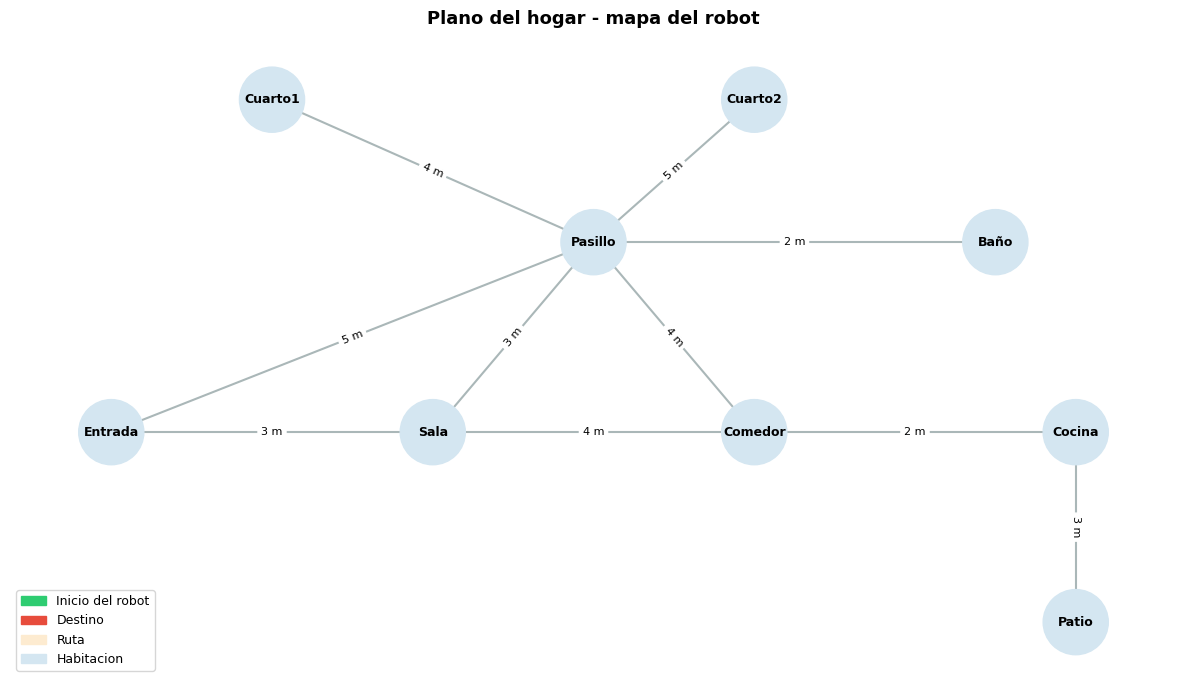

In [34]:
# ============================================================
# CELDA 15 — MAPA DEL HOGAR
# ============================================================

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Definimos el mapa del hogar como un grafo
# Los pesos representan distancia en metros
mapa_hogar = {
    'Entrada':    [('Sala', 3), ('Pasillo', 5)],
    'Sala':       [('Entrada', 3), ('Comedor', 4), ('Pasillo', 3)],
    'Comedor':    [('Sala', 4), ('Cocina', 2), ('Pasillo', 4)],
    'Cocina':     [('Comedor', 2), ('Patio', 3)],
    'Pasillo':    [('Entrada', 5), ('Sala', 3), ('Comedor', 4),
                   ('Cuarto1', 4), ('Cuarto2', 5), ('Baño', 2)],
    'Cuarto1':    [('Pasillo', 4)],
    'Cuarto2':    [('Pasillo', 5)],
    'Baño':       [('Pasillo', 2)],
    'Patio':      [('Cocina', 3)]
}

# Posiciones del mapa para la visualización
# Se acomodan como si fuera una planta simple de una casa
pos_hogar = {
    'Entrada':  (0, 0),
    'Sala':     (2, 0),
    'Comedor':  (4, 0),
    'Cocina':   (6, 0),
    'Patio':    (6, -2),
    'Pasillo':  (3, 2),
    'Cuarto1':  (1, 3.5),
    'Cuarto2':  (4, 3.5),
    'Baño':     (5.5, 2)
}

def visualizar_hogar(mapa, pos, titulo, camino=None, inicio=None, fin=None):
    """Visualiza el mapa del hogar con el camino del robot."""

    # 1. Creamos un grafo no dirigido
    G = nx.Graph()

    # 2. Agregamos nodos y aristas con peso
    for nodo, vecinos in mapa.items():
        for vecino, costo in vecinos:
            G.add_edge(nodo, vecino, weight=costo)

    # 3. Asignamos colores por defecto
    colores = {}
    for nodo in G.nodes():
        colores[nodo] = '#D4E6F1'  # azul claro = habitacion normal

    # 4. Si hay una ruta, la pintamos
    if camino:
        for nodo in camino:
            colores[nodo] = '#FDEBD0'  # naranja claro = ruta

    # 5. Resaltamos inicio y destino
    if inicio:
        colores[inicio] = '#2ECC71'   # verde = inicio
    if fin:
        colores[fin] = '#E74C3C'      # rojo = destino

    # 6. Convertimos el diccionario de colores en lista
    color_lista = [colores.get(n, '#D4E6F1') for n in G.nodes()]

    # 7. Creamos la figura
    fig, ax = plt.subplots(figsize=(12, 7))

    # 8. Dibujamos aristas del camino con mayor grosor
    if camino and len(camino) > 1:
        aristas_camino = [(camino[i], camino[i + 1]) for i in range(len(camino) - 1)]
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=aristas_camino,
            edge_color='#E67E22',
            width=4,
            ax=ax
        )

    # 9. Dibujamos todo el grafo
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color=color_lista,
        node_size=2200,
        font_size=9,
        font_weight='bold',
        edge_color='#AAB7B8',
        width=1.5,
        ax=ax
    )

    # 10. Dibujamos los pesos de las aristas
    edge_labels = nx.get_edge_attributes(G, 'weight')
    edge_labels = {k: f"{v} m" for k, v in edge_labels.items()}
    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=8,
        ax=ax
    )

    # 11. Leyenda sin emojis para evitar warnings
    leyenda = [
        mpatches.Patch(color='#2ECC71', label='Inicio del robot'),
        mpatches.Patch(color='#E74C3C', label='Destino'),
        mpatches.Patch(color='#FDEBD0', label='Ruta'),
        mpatches.Patch(color='#D4E6F1', label='Habitacion'),
    ]
    ax.legend(handles=leyenda, loc='lower left', fontsize=9)

    # 12. Título
    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=15)

    plt.tight_layout()
    plt.show()

print("Mapa del hogar cargado")
print(f"Habitaciones: {list(mapa_hogar.keys())}")
print()

visualizar_hogar(
    mapa_hogar,
    pos_hogar,
    "Plano del hogar - mapa del robot"
)

🤖 ROBOT DOMÉSTICO — MISIÓN 1
Escenario: El abuelo dejó sus medicamentos en la Cocina
y está en la Sala. El robot debe traerlos.

Ruta: Sala (robot) → Cocina (medicamentos)

   Heurísticas hacia 'Cocina':
     Cocina      :   0.0 m estimados
     Comedor     :   3.0 m estimados
     Patio       :   3.0 m estimados
     Baño        :   3.1 m estimados
     Pasillo     :   5.4 m estimados
     Sala        :   6.0 m estimados
     Cuarto2     :   6.0 m estimados
     Entrada     :   9.0 m estimados
     Cuarto1     :   9.2 m estimados

✅ Ruta óptima: Sala → Comedor → Cocina
   Distancia total: 6 metros
   Batería usada: ~12 unidades de energía


/tmp/ipykernel_1207/3564704763.py:120: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


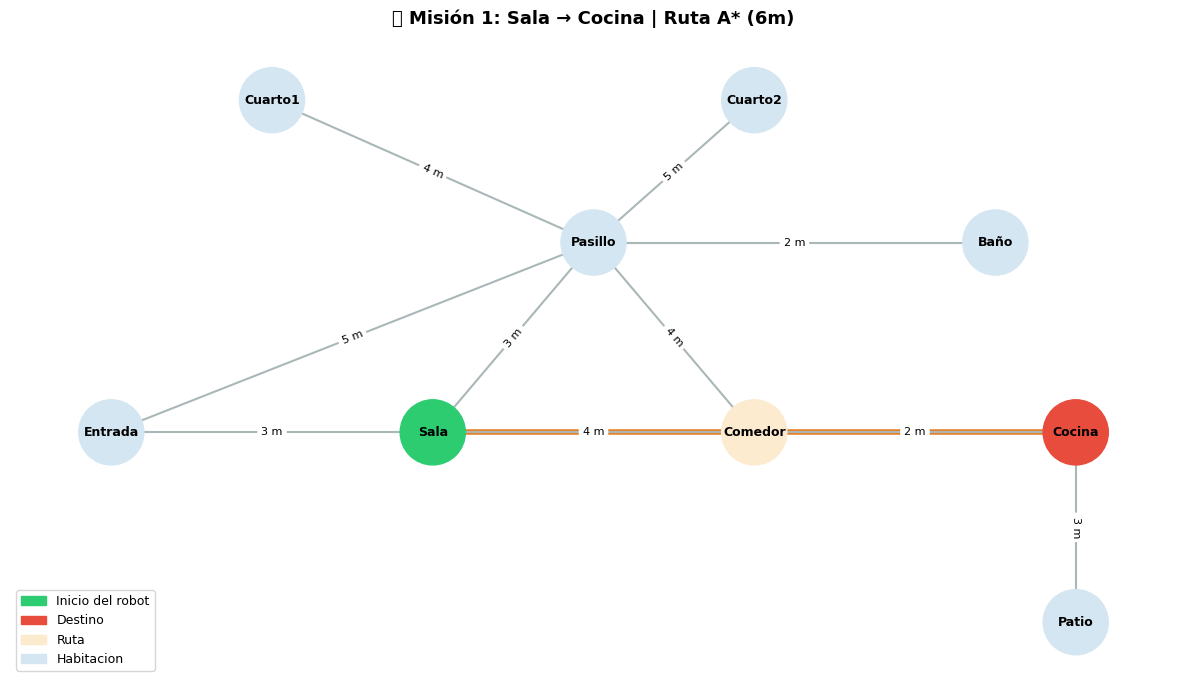

In [35]:
# ============================================================
# CELDA 16 — HEURÍSTICA PARA EL HOGAR
# ============================================================

# La heurística es la distancia Manhattan aproximada a cada destino posible.
# En un robot real, se calcularía con coordenadas GPS internas.

def heuristica_hogar(nodo, objetivo, posiciones):
    """
    Calcula la distancia Euclidiana entre dos habitaciones.
    Esta es la heurística admisible para A* en el hogar.

    La distancia euclidiana nunca sobreestima la distancia real
    porque el camino real siempre es igual o más largo.
    """
    x1, y1 = posiciones[nodo]
    x2, y2 = posiciones[objetivo]
    # Convertimos unidades del gráfico a metros (factor ~1.5)
    distancia = math.sqrt((x2-x1)**2 + (y2-y1)**2) * 1.5
    return round(distancia, 1)


def a_estrella_hogar(mapa, posiciones, inicio, objetivo):
    """
    A* adaptado para el robot en el hogar.
    Calcula la heurística dinámicamente usando las posiciones.
    """
    # Construimos el diccionario de heurísticas para este objetivo
    h = {nodo: heuristica_hogar(nodo, objetivo, posiciones)
         for nodo in mapa}

    print(f"   Heurísticas hacia '{objetivo}':")
    for nodo, valor in sorted(h.items(), key=lambda x: x[1]):
        print(f"     {nodo:12s}: {valor:5.1f} m estimados")
    print()

    camino, costo, explorados = a_estrella(mapa, inicio, objetivo, h)
    return camino, costo, explorados


print("=" * 60)
print("🤖 ROBOT DOMÉSTICO — MISIÓN 1")
print("=" * 60)
print("Escenario: El abuelo dejó sus medicamentos en la Cocina")
print("y está en la Sala. El robot debe traerlos.")
print()
print("Ruta: Sala (robot) → Cocina (medicamentos)")
print()

camino_m1, costo_m1, _ = a_estrella_hogar(
    mapa_hogar, pos_hogar, 'Sala', 'Cocina'
)

print(f"✅ Ruta óptima: {' → '.join(camino_m1)}")
print(f"   Distancia total: {costo_m1} metros")
print(f"   Batería usada: ~{costo_m1 * 2} unidades de energía")

visualizar_hogar(
    mapa_hogar, pos_hogar,
    f"🤖 Misión 1: Sala → Cocina | Ruta A* ({costo_m1}m)",
    camino=camino_m1, inicio='Sala', fin='Cocina'
)

ROBOT DOMESTICO - MISION 1
Escenario: El abuelo dejo sus medicamentos en la Cocina
y esta en la Sala. El robot debe traerlos.

Ruta: Sala (robot) -> Cocina (medicamentos)

   Heuristicas hacia 'Cocina':
     Cocina      :   0.0 m estimados
     Comedor     :   3.0 m estimados
     Patio       :   3.0 m estimados
     Baño        :   3.1 m estimados
     Pasillo     :   5.4 m estimados
     Sala        :   6.0 m estimados
     Cuarto2     :   6.0 m estimados
     Entrada     :   9.0 m estimados
     Cuarto1     :   9.2 m estimados

Ruta optima: Sala -> Comedor -> Cocina
Distancia total: 6 metros
Bateria usada: ~12 unidades de energia


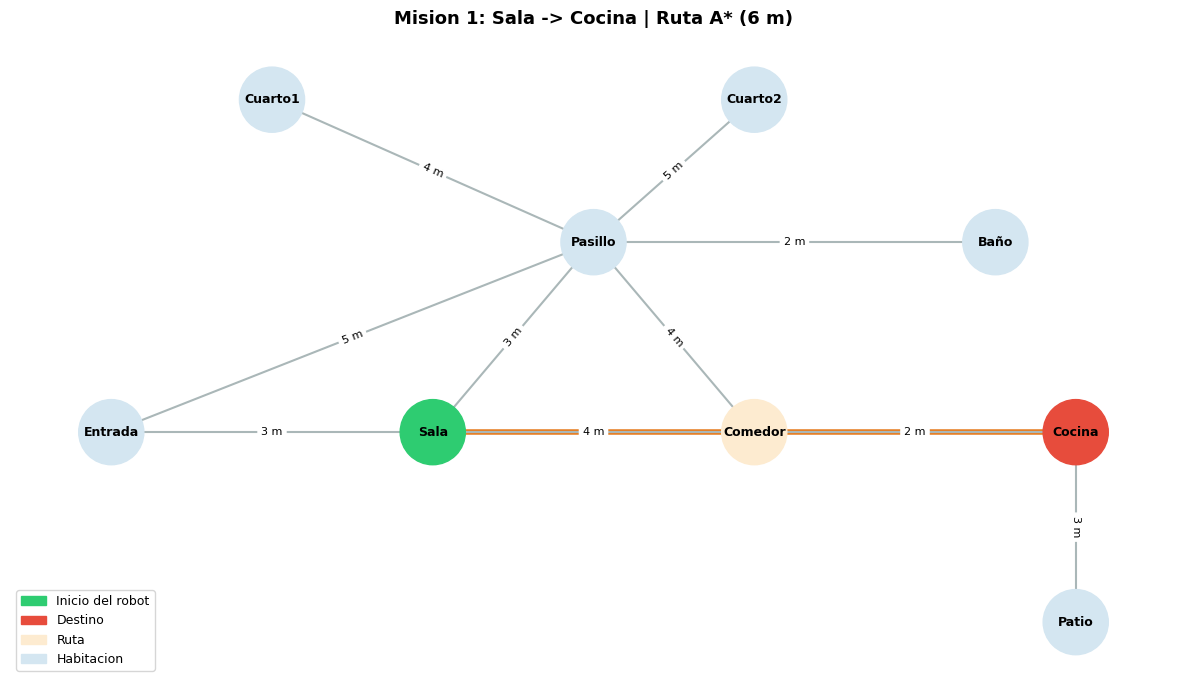

In [36]:
# ============================================================
# CELDA 16 — HEURISTICA PARA EL HOGAR
# ============================================================

import math

# La heurística representa una estimación de la distancia
# entre una habitación y el objetivo.
# Aquí usamos la distancia euclidiana basada en las posiciones
# del plano del hogar.

def heuristica_hogar(nodo, objetivo, posiciones):
    """
    Calcula la distancia euclidiana entre dos habitaciones.
    Esta es una heurística admisible para A* en el mapa del hogar.

    La distancia euclidiana no sobreestima la distancia real
    si el recorrido real debe seguir caminos conectados.
    """
    x1, y1 = posiciones[nodo]
    x2, y2 = posiciones[objetivo]

    # Convertimos las unidades del plano a una escala aproximada en metros
    distancia = math.sqrt((x2 - x1)**2 + (y2 - y1)**2) * 1.5

    return round(distancia, 1)


def a_estrella_hogar(mapa, posiciones, inicio, objetivo):
    """
    Ejecuta A* en el mapa del hogar.
    La heurística se calcula dinámicamente con base en la posición
    de cada habitación respecto al objetivo.
    """

    # 1. Construimos el diccionario de heurísticas
    h = {
        nodo: heuristica_hogar(nodo, objetivo, posiciones)
        for nodo in mapa
    }

    # 2. Mostramos las heurísticas calculadas
    print(f"   Heuristicas hacia '{objetivo}':")
    for nodo, valor in sorted(h.items(), key=lambda x: x[1]):
        print(f"     {nodo:12s}: {valor:5.1f} m estimados")
    print()

    # 3. Ejecutamos el algoritmo A*
    camino, costo, explorados = a_estrella(mapa, inicio, objetivo, h)

    return camino, costo, explorados


print("=" * 60)
print("ROBOT DOMESTICO - MISION 1")
print("=" * 60)
print("Escenario: El abuelo dejo sus medicamentos en la Cocina")
print("y esta en la Sala. El robot debe traerlos.")
print()
print("Ruta: Sala (robot) -> Cocina (medicamentos)")
print()

camino_m1, costo_m1, _ = a_estrella_hogar(
    mapa_hogar,
    pos_hogar,
    'Sala',
    'Cocina'
)

print(f"Ruta optima: {' -> '.join(camino_m1)}")
print(f"Distancia total: {costo_m1} metros")
print(f"Bateria usada: ~{costo_m1 * 2} unidades de energia")

visualizar_hogar(
    mapa_hogar,
    pos_hogar,
    f"Mision 1: Sala -> Cocina | Ruta A* ({costo_m1} m)",
    camino=camino_m1,
    inicio='Sala',
    fin='Cocina'
)

In [37]:
# ============================================================
# CELDA 18 — MISION 3: ROBOT CON BATERIA LIMITADA
# ============================================================

# Simulamos que el robot tiene bateria baja y necesita
# saber si puede completar la misión antes de quedarse sin energia.

print("=" * 60)
print("ROBOT DOMESTICO - MISION 3 (bateria limitada)")
print("=" * 60)


class RobotDomestico:
    """
    Robot domestico con sistema de navegacion inteligente.
    Integra A* para planificacion de rutas.
    """

    def __init__(self, nombre, mapa, posiciones, posicion_inicial, bateria=50):
        self.nombre = nombre
        self.mapa = mapa
        self.posiciones = posiciones
        self.posicion = posicion_inicial
        self.bateria = bateria       # metros que puede recorrer
        self.historial = [posicion_inicial]

        print(f"{self.nombre} inicializado")
        print(f"   Posicion: {self.posicion}")
        print(f"   Bateria:  {self.bateria} m disponibles")

    def ir_a(self, destino):
        """
        Planifica y ejecuta el movimiento al destino.
        """
        print(f"\n   Nueva mision: {self.posicion} -> {destino}")

        if destino == self.posicion:
            print("   Ya estoy en el destino")
            return True

        # Planificacion con A*
        h = {
            nodo: heuristica_hogar(nodo, destino, self.posiciones)
            for nodo in self.mapa
        }

        camino, costo, _ = a_estrella(self.mapa, self.posicion, destino, h)

        if camino is None:
            print("   No hay ruta disponible")
            return False

        print(f"   Ruta planificada: {' -> '.join(camino)} ({costo} m)")

        # Verificar bateria
        if costo > self.bateria:
            print(f"   BATERIA INSUFICIENTE: necesito {costo} m, tengo {self.bateria} m")
            print("   Buscando estacion de carga mas cercana...")
            return False

        # Ejecutar movimiento
        self.bateria -= costo
        self.posicion = destino
        self.historial.extend(camino[1:])

        print("   Mision completada")
        print(f"   Bateria restante: {self.bateria} m")

        return True

    def reporte(self):
        """Muestra el estado actual del robot."""
        print(f"\nREPORTE DE {self.nombre}")
        print(f"   Posicion actual: {self.posicion}")
        print(f"   Bateria:         {self.bateria} m")
        print(f"   Ruta total:      {' -> '.join(self.historial)}")


# ------------------------------------------------------------
# SIMULACION DEL DIA DEL ROBOT
# ------------------------------------------------------------

print()
robot = RobotDomestico("ROMI-7", mapa_hogar, pos_hogar, "Entrada", bateria=25)

print("\n" + "=" * 45)
print("Simulando jornada del robot...")
print("=" * 45)

robot.ir_a('Cuarto1')   # Mision 1
robot.ir_a('Cocina')    # Mision 2
robot.ir_a('Patio')     # Mision 3

robot.reporte()

ROBOT DOMESTICO - MISION 3 (bateria limitada)

ROMI-7 inicializado
   Posicion: Entrada
   Bateria:  25 m disponibles

Simulando jornada del robot...

   Nueva mision: Entrada -> Cuarto1
   Ruta planificada: Entrada -> Pasillo -> Cuarto1 (9 m)
   Mision completada
   Bateria restante: 16 m

   Nueva mision: Cuarto1 -> Cocina
   Ruta planificada: Cuarto1 -> Pasillo -> Comedor -> Cocina (10 m)
   Mision completada
   Bateria restante: 6 m

   Nueva mision: Cocina -> Patio
   Ruta planificada: Cocina -> Patio (3 m)
   Mision completada
   Bateria restante: 3 m

REPORTE DE ROMI-7
   Posicion actual: Patio
   Bateria:         3 m
   Ruta total:      Entrada -> Pasillo -> Cuarto1 -> Pasillo -> Comedor -> Cocina -> Patio


In [38]:
# ============================================================
# CELDA 19 — COMPARATIVA DE ALGORITMOS EN EL HOGAR
# ============================================================
# Comparamos todos los algoritmos resolviendo el mismo problema
# del robot y medimos cuántos nodos exploran y cuánto tardan.

print("=" * 65)
print("📊 BENCHMARKING: Todos los algoritmos en el mapa del hogar")
print("   Problema: Entrada → Cuarto2")
print("=" * 65)
print()

INICIO = 'Entrada'
DESTINO = 'Cuarto2'

h_hogar = {n: heuristica_hogar(n, DESTINO, pos_hogar) for n in mapa_hogar}

resultados = []

# BFS
t0 = time.time()
cam, orden = bfs(mapa_hogar, INICIO, DESTINO)
t1 = time.time()
resultados.append(('BFS', cam, calcular_costo(mapa_hogar, cam), len(orden), round((t1-t0)*1000, 3)))

# DFS
t0 = time.time()
cam, orden = dfs(mapa_hogar, INICIO, DESTINO)
t1 = time.time()
resultados.append(('DFS', cam, calcular_costo(mapa_hogar, cam), len(orden), round((t1-t0)*1000, 3)))

# A*
t0 = time.time()
cam, costo, expl = a_estrella(mapa_hogar, INICIO, DESTINO, h_hogar)
t1 = time.time()
resultados.append(('A*', cam, costo, len(expl), round((t1-t0)*1000, 3)))

# IDS
t0 = time.time()
cam, _ = ids(mapa_hogar, INICIO, DESTINO)
t1 = time.time()
resultados.append(('IDS', cam, calcular_costo(mapa_hogar, cam) if cam else 0,
                   'N/A', round((t1-t0)*1000, 3)))

print()
print(f"{'Algoritmo':<15} {'Ruta':35} {'Costo':>6} {'Nodos':>7} {'Tiempo':>9}")
print("-" * 78)
for algo, camino, costo, nodos, t in resultados:
    ruta = ' → '.join(camino) if camino else 'No encontrado'
    print(f"{algo:<15} {ruta:35} {str(costo)+'m':>6} {str(nodos):>7} {str(t)+'ms':>9}")
print("-" * 78)

print()
print("💡 CONCLUSIÓN para el Robot Doméstico:")
print("   ✅ A* es la mejor opción: encuentra la ruta MÁS CORTA")
print("      explorando el MENOR número de habitaciones.")
print("   ✅ Esto maximiza la vida de la batería del robot.")

📊 BENCHMARKING: Todos los algoritmos en el mapa del hogar
   Problema: Entrada → Cuarto2

   Iterando límites de profundidad...
   🔍 Probando profundidad límite: 0  — no encontrado
   🔍 Probando profundidad límite: 1  — no encontrado
   🔍 Probando profundidad límite: 2  ← ✅ ENCONTRADO

Algoritmo       Ruta                                 Costo   Nodos    Tiempo
------------------------------------------------------------------------------
BFS             Entrada → Pasillo → Cuarto2            10m       6   0.151ms
DFS             Entrada → Pasillo → Cuarto2            10m       8   0.131ms
A*              Entrada → Pasillo → Cuarto2            10m       4   0.131ms
IDS             Entrada → Pasillo → Cuarto2            10m     N/A   0.186ms
------------------------------------------------------------------------------

💡 CONCLUSIÓN para el Robot Doméstico:
   ✅ A* es la mejor opción: encuentra la ruta MÁS CORTA
      explorando el MENOR número de habitaciones.
   ✅ Esto maximiza la vid

---
## 🧪 EJERCICIOS PROPUESTOS

Ahora es tu turno. Completa los siguientes ejercicios para consolidar tu aprendizaje:

---

In [39]:
# ============================================================
# EJERCICIO 1 — Agrega una habitación al hogar
# ============================================================
# Instrucciones:
# 1. Agrega una habitación llamada 'Garage' conectada a 'Entrada' con 4m
# 2. Corre A* desde Cuarto2 hasta Garage
# 3. Visualiza la ruta en el mapa

# TU CÓDIGO AQUÍ:
mapa_ejercicio1 = copy.deepcopy(mapa_hogar)
pos_ejercicio1 = dict(pos_hogar)

# Pista: mapa_ejercicio1['Garage'] = [('Entrada', 4)]
#        mapa_ejercicio1['Entrada'].append(('Garage', 4))
#        pos_ejercicio1['Garage'] = (-2, 0)

print("📝 Ejercicio 1: Agrega el Garage y corre A*")
print("   Completa el código anterior y ejecuta esta celda")

📝 Ejercicio 1: Agrega el Garage y corre A*
   Completa el código anterior y ejecuta esta celda


In [40]:
# ============================================================
# EJERCICIO 2 — Implementa BFS en el mapa del hogar
# ============================================================
# Instrucciones:
# 1. Usa BFS para encontrar el camino de Patio a Cuarto1
# 2. Compara el resultado con A*
# 3. ¿El costo en metros es el mismo o diferente?

print("📝 Ejercicio 2: BFS de Patio a Cuarto1")
print()
print("# Completa:")
print("# camino_ej2, orden_ej2 = bfs(mapa_hogar, 'Patio', 'Cuarto1')")
print("# print(camino_ej2)")

📝 Ejercicio 2: BFS de Patio a Cuarto1

# Completa:
# camino_ej2, orden_ej2 = bfs(mapa_hogar, 'Patio', 'Cuarto1')
# print(camino_ej2)


In [41]:
# ============================================================
# EJERCICIO 3 — Minimax para Tres en Raya
# ============================================================
# Instrucciones:
# Cambia el estado inicial del tablero y observa qué movimiento
# elige Minimax. ¿Siempre elige el movimiento ganador?

print("📝 Ejercicio 3: Prueba Minimax con este tablero")
print()

tablero_ej3 = ['X', ' ', 'O',
               ' ', 'X', ' ',
               'O', ' ', ' ']

mostrar_tablero(tablero_ej3, "Tablero inicial (turno de X):")
print()

# Completa: ¿cuál es el mejor movimiento?
# mov, val = mejor_jugada(tablero_ej3)
# print(f"Minimax elige posición: {mov}")
print("# Descomenta las líneas anteriores para resolver")

📝 Ejercicio 3: Prueba Minimax con este tablero

   Tablero inicial (turno de X):
   X |   | O
   ---------
     | X |  
   ---------
   O |   |  

# Descomenta las líneas anteriores para resolver


---
## 🎓 RESUMEN FINAL Y REFLEXIONES

### Lo que aprendiste hoy:

| Algoritmo | Fortaleza | Cuándo usarlo |
|-----------|-----------|---------------|
| **BFS** | Encuentra el camino más corto (pasos) | Grafos sin peso, laberintos |
| **DFS** | Usa poca memoria | Exploración completa, backtracking |
| **A\*** | Óptimo y eficiente con heurística | Navegación, mapas, juegos |
| **IDS** | Lo mejor de BFS+DFS | Cuando hay restricción de memoria |
| **Bidireccional** | Muy eficiente en grafos grandes | GPS, redes de transporte |
| **Hill Climbing** | Ultra rápido | Optimización, cuando no importa el óptimo |
| **Beam Search** | Compromiso memoria/calidad | NLP, reconocimiento de voz |
| **Minimax** | Juego adversarial óptimo | Ajedrez, damas, tres en raya |

### Caso de estudio aplicado:
✅ Implementamos un **robot doméstico inteligente** que usa A* para:
- Navegar entre habitaciones
- Evitar obstáculos
- Gestionar su batería
- Planificar múltiples misiones

### Conexión con el mundo real:
- 🚗 **Google Maps / Waze** → A* y variantes para rutas
- 🎮 **Videojuegos (NPCs)** → A*, Minimax para decisiones de IA
- 🤖 **Robots (Roomba, drones)** → A* para navegación
- 🌐 **Redes de telecomunicaciones** → BFS/DFS para enrutamiento
- 🧬 **Bioinformática** → BFS para análisis de proteínas

---

> *"La inteligencia artificial no es sobre máquinas que piensan como humanos,*  
> *sino sobre algoritmos que resuelven problemas que los humanos encuentran difíciles."*

---
**Universidad Autónoma de Nayarit — Sistemas Inteligentes**  
Dr. Oscar Gabriel Vizcaíno Monroy